# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s): Cameron Barlow** 

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [51]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [52]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [53]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [54]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


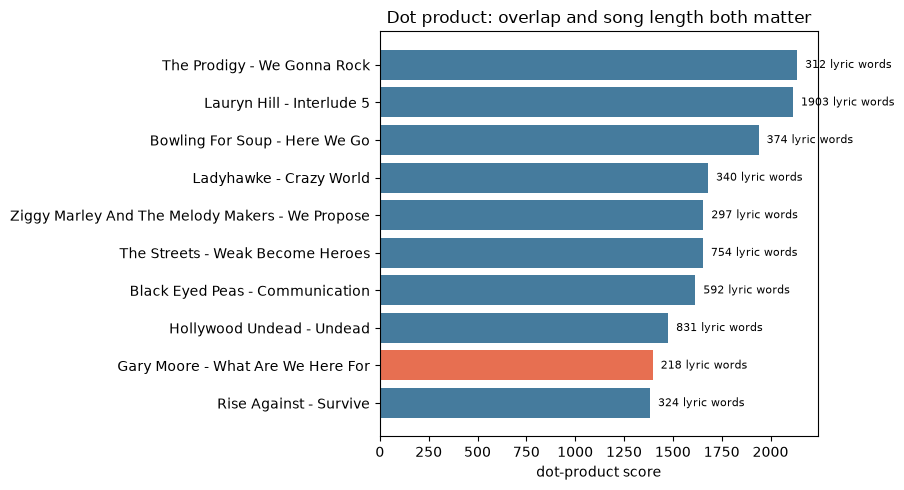

In [55]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [56]:
top_40_results = top_40.copy()
for query_idx in top_40_results.index:
    query = X[query_idx]
    scores = X @ query
    scores[query_idx] = -np.inf
    top_matches = np.argsort(scores)[-3:][::-1] #largest scores at end, so why I get last 3 here, and then reverse order
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_results.loc[query_idx, f"match_{rank}_artist"] = (songs.loc[match_idx, "artist_name"])
        top_40_results.loc[query_idx, f"match_{rank}_title"] = (songs.loc[match_idx, "song_title"])
        top_40_results.loc[query_idx, f"match_{rank}_score"] = scores[match_idx]
top_40_results.to_csv("./data/top_40_songs_by_genre_results.csv",index=False)

In looking at the top matches, We Gonna Rock and Interlude 5 seem to be seen as most similar when using the dot product because of their song length. Certainly with Interlude 5, this is a very long song, which can be why it has such a high dot product. Thus, it does certainly seem song length plays a huge role in similarity. Though, one thing to note is that we is used a lot in these songs, which could also be playing a large role in the song similarity.

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [57]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2063.720,2.579650
5478,TRVLIZK128F428845E,SOGLUJL12A8C138E31,ARUN7IC1187FB3D392,Five,That's What You Told Me,Five,1998,222.92853,0.588017,0.435445,pop,5ive; pop; Favorite; boybands; Remember,593,95,153.277526,0,1857.140,2.321425
6624,TRUGLTC128F4227B93,SOUSFNM12A6D4FCDAD,AR4503S1187FB43199,Danity Kane,Hold Me Down (Album Version),Danity Kane,2006,237.60934,0.854298,0.531303,r&b/soul,dance; Hold Me Down; Danity Kane; rnb; party,766,149,159.499216,0,1833.570,2.291962
6380,TRJYWGA128F428B005,SOOQDTH12A8C1390CA,ARKTHKM1187B9B59A4,Phyllis Hyman,You Know How To Love Me,The Legacy Of Phyllis Hyman,1996,452.46649,0.578440,0.481931,r&b/soul,soul; Disco; female vocalists; Phyllis Hyman; ...,554,119,113.960519,0,1526.835,1.908544
6202,TRCGAVX12903CFBC61,SOHQFVC12A58A7B234,ARDAF601187FB4CD05,Ashanti,Rock Wit U (Awww Baby),Def Jam 25_ Vol. 19 - For The Lover In You,2003,209.21424,0.801795,0.494343,r&b/soul,rnb; Ashanti; female vocalists; pop; soul,522,84,108.365124,0,1313.915,1.642394
6300,TRGFXCY128F42A6AD7,SOONWSO12A8C13EB72,ARDSMT71187FB52D10,Avant,Hooked,Private Room,2003,239.12444,0.850584,0.573337,r&b/soul,rnb; r and b; slow jams; slowjamz; avant,732,161,111.870461,0,1293.185,1.616481
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,1261.370,1.576712
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,1238.385,1.547981
6621,TRUEPSG128F149639E,SOJPWZI12A6701D00C,ARUM60L1187B9A7E1F,Stevie Wonder,All Day Sucker,The Complete Stevie Wonder,1976,305.65832,0.757921,0.600265,r&b/soul,soul; funk; 70s; Stevie Wonder; motown,629,89,147.064612,0,1218.580,1.523225
3648,TRSWFAJ128F1495907,SOMXVLQ12A6D4F9DF3,ARL6HUT1187FB4D9C2,Bell Biv DeVoe,Do Me!,20th Century Masters: The Millennium Collectio...,1990,326.32118,0.630370,0.444190,jazz,new jack swing; rnb; 90s; dance; old school,459,103,111.018017,0,1196.195,1.495244


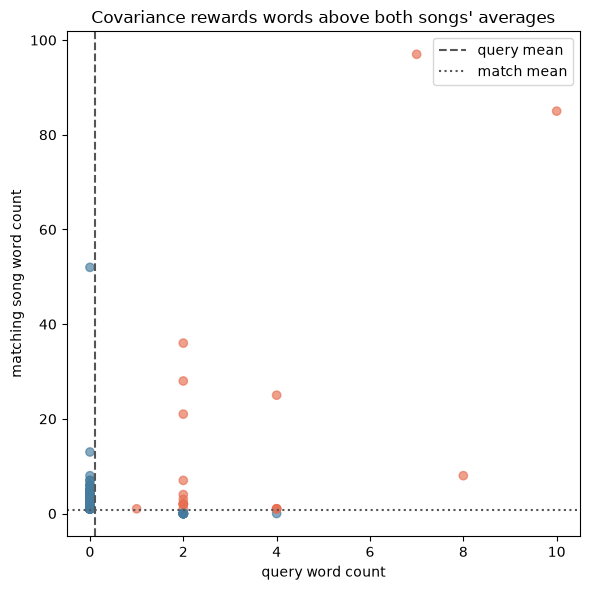

In [58]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In looking at the rankings, it seems that is not many common songs in both rankings in the top 10. However, I am still noticing, maybe even more so with the covariance metric, that there are many long songs in the top matches. There are a few songs in the top 10 of covariance similarity with over 1000 total words, more than the dot product. Subtracting the mean changes the notion of similarity because now we are looking at how similar songs are in compared to their own averages, not just comparing 2 songs side by side by magnitude.

In [59]:
for query_idx in top_40_results.index:
    query = X[query_idx]
    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    centered_scores = X_centered @ query_centered
    centered_scores[query_idx] = -np.inf
    top_matches = np.argsort(centered_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_results.loc[query_idx, f"centered_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_results.loc[query_idx, f"centered_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_results.loc[query_idx, f"centered_match_{rank}_score"] = centered_scores[match_idx]
top_40_results.to_csv("./data/top_40_songs_by_genre_results.csv",index=False)

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [60]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
559,TRZANFO128F425A854,SODGTGI12A8AE472A3,AR6BJ1V1187B9AE3B7,Fleetwood Mac,Like It This Way,Blues Jam In Chicago - Volume 2,1969,264.59383,0.747904,0.576036,blues,blues rock; blues; 60s; rock; Fleetwood Mac,99,37,19.646883,0,1.000000
1339,TRVEXTN128F145FEFD,SONBNVW12A6D4F6295,AR7SF1N1187B9A91D1,John Berry,Your Love Amazes Me,Greatest Hits,0,234.68363,0.566014,0.463772,country,country; lovesong; love songs; Favourite Songs...,171,71,28.460499,0,0.737989
1085,TRKQESA128F4275C67,SOUNRLC12A8C138114,ARRY64L1187FB57E38,Steve Wariner,Love Me Like You Love Me,Burnin' The Roadhouse Down,1998,246.98730,0.542306,0.472603,country,country; damn; YEAH i do; the ones that hit my...,224,104,38.781439,0,0.719941
6380,TRJYWGA128F428B005,SOOQDTH12A8C1390CA,ARKTHKM1187B9B59A4,Phyllis Hyman,You Know How To Love Me,The Legacy Of Phyllis Hyman,1996,452.46649,0.578440,0.481931,r&b/soul,soul; Disco; female vocalists; Phyllis Hyman; ...,554,119,113.960519,0,0.698982
6693,TRXKSAZ12903CAFB8E,SOYZWQN12AB018785F,AROQMWV1187FB3781A,Jill Scott,He Loves Me (Lyzel In E Flat),Jill Scott Live In Paris,2000,661.23710,0.814623,0.530315,r&b/soul,soul; Neo-Soul; rnb; Love; jazz,184,61,47.286362,0,0.696803
379,TRRFMYC128EF348C72,SOFPUCR12A6D4F7F34,AR4GAFY1187B9B639D,B.B. King,You Done Lost Your Good Thing Now,The Blues Anthology,1965,315.53261,0.708735,0.542290,blues,blues; over 5 minutes long; Ballad; blues rock...,268,67,52.019227,0,0.690910
5116,TRGTQCP128F932573A,SOXGDGO12D021B3D6B,ARWS1TU1187B9B2560,Hilary Duff,Play With Fire,Best Of Hilary Duff,2007,181.52444,0.803470,0.554576,pop,pop; hilary duff; dance; female vocalists; pop...,404,134,63.063460,0,0.685671
6376,TRJVRGE128F149E808,SOVRGKD12A6D4F738D,ARISHTQ1187FB3E6F0,Ben E. King,Supernatural Thing Part 1,The Ultimate Collection,0,248.60689,0.688639,0.478780,r&b/soul,soul and rnb classics,194,66,37.282704,0,0.673286
3196,TRAEPAC12903CE5DC8,SOELRRQ12AB0188C34,AR20CFC1187B98A25D,Ray Charles,Let's Go,Genius + Soul = Jazz,0,160.93995,0.759913,0.673207,jazz,ray charles; garden party; Songs to Read By; d...,155,60,32.802439,0,0.661806
6249,TRDZDEZ128F930CC4D,SOXANJZ12A8C137903,ARAHQDS1187FB55275,Maysa,Love Won't Let Me Wait,Sweet Classic Soul,0,264.61995,0.616437,0.409465,r&b/soul,maysa; soul; funk; rnb; Incognito,198,95,28.442925,0,0.654278


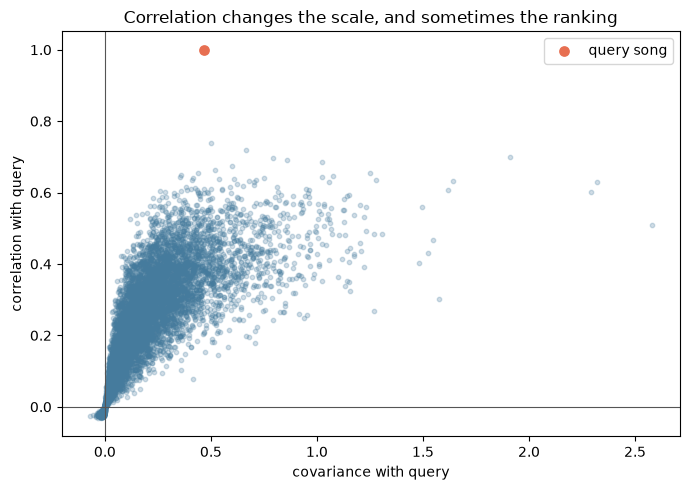

In [61]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

A song might move up if it has a similar pattern of word usage relative to its own mean, even if its overall variation is smaller. A song that might move down is one that had a chigh covariance because of having higher values and larger variation (which could certainly be because of longer songs). For example, long songs are not seen as often in the correlation.

In [62]:
for query_idx in top_40_results.index:
    query = X[query_idx]
    query_std = query.std()
    X_std = X.std(axis=1)
    denom = X_std * query_std
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )
    corr_scores[query_idx] = -np.inf
    top_matches = np.argsort(corr_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_results.loc[query_idx, f"correlation_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_results.loc[query_idx, f"correlation_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_results.loc[query_idx, f"correlation_match_{rank}_score"] = corr_scores[match_idx]
top_40_results.to_csv("./data/top_40_songs_by_genre_results.csv",index=False)

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [63]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
559,TRZANFO128F425A854,SODGTGI12A8AE472A3,AR6BJ1V1187B9AE3B7,Fleetwood Mac,Like It This Way,Blues Jam In Chicago - Volume 2,1969,264.59383,0.747904,0.576036,blues,blues rock; blues; 60s; rock; Fleetwood Mac,99,37,19.646883,0,1.000000
1339,TRVEXTN128F145FEFD,SONBNVW12A6D4F6295,AR7SF1N1187B9A91D1,John Berry,Your Love Amazes Me,Greatest Hits,0,234.68363,0.566014,0.463772,country,country; lovesong; love songs; Favourite Songs...,171,71,28.460499,0,0.745761
1085,TRKQESA128F4275C67,SOUNRLC12A8C138114,ARRY64L1187FB57E38,Steve Wariner,Love Me Like You Love Me,Burnin' The Roadhouse Down,1998,246.98730,0.542306,0.472603,country,country; damn; YEAH i do; the ones that hit my...,224,104,38.781439,0,0.728409
6380,TRJYWGA128F428B005,SOOQDTH12A8C1390CA,ARKTHKM1187B9B59A4,Phyllis Hyman,You Know How To Love Me,The Legacy Of Phyllis Hyman,1996,452.46649,0.578440,0.481931,r&b/soul,soul; Disco; female vocalists; Phyllis Hyman; ...,554,119,113.960519,0,0.706129
6693,TRXKSAZ12903CAFB8E,SOYZWQN12AB018785F,AROQMWV1187FB3781A,Jill Scott,He Loves Me (Lyzel In E Flat),Jill Scott Live In Paris,2000,661.23710,0.814623,0.530315,r&b/soul,soul; Neo-Soul; rnb; Love; jazz,184,61,47.286362,0,0.701808
379,TRRFMYC128EF348C72,SOFPUCR12A6D4F7F34,AR4GAFY1187B9B639D,B.B. King,You Done Lost Your Good Thing Now,The Blues Anthology,1965,315.53261,0.708735,0.542290,blues,blues; over 5 minutes long; Ballad; blues rock...,268,67,52.019227,0,0.699598
5116,TRGTQCP128F932573A,SOXGDGO12D021B3D6B,ARWS1TU1187B9B2560,Hilary Duff,Play With Fire,Best Of Hilary Duff,2007,181.52444,0.803470,0.554576,pop,pop; hilary duff; dance; female vocalists; pop...,404,134,63.063460,0,0.695722
6376,TRJVRGE128F149E808,SOVRGKD12A6D4F738D,ARISHTQ1187FB3E6F0,Ben E. King,Supernatural Thing Part 1,The Ultimate Collection,0,248.60689,0.688639,0.478780,r&b/soul,soul and rnb classics,194,66,37.282704,0,0.682604
3196,TRAEPAC12903CE5DC8,SOELRRQ12AB0188C34,AR20CFC1187B98A25D,Ray Charles,Let's Go,Genius + Soul = Jazz,0,160.93995,0.759913,0.673207,jazz,ray charles; garden party; Songs to Read By; d...,155,60,32.802439,0,0.670323
6249,TRDZDEZ128F930CC4D,SOXANJZ12A8C137903,ARAHQDS1187FB55275,Maysa,Love Won't Let Me Wait,Sweet Classic Soul,0,264.61995,0.616437,0.409465,r&b/soul,maysa; soul; funk; rnb; Incognito,198,95,28.442925,0,0.665695


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

The similar songs engine is more of the cosine-similarity ranking, while the shares lots of raw word mass engine is more of the dot-product ranking. I say this because since the cosine-similarity ranking divides by the length of both vectors, it truly focuses on song similarity and pattern rather than length of the song.

In [64]:
for query_idx in top_40_results.index:
    query = X[query_idx]
    cos_scores = cosine_scores(X, query)
    cos_scores[query_idx] = -np.inf
    top_matches = np.argsort(cos_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_results.loc[query_idx, f"cosine_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_results.loc[query_idx, f"cosine_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_results.loc[query_idx, f"cosine_match_{rank}_score"] = cos_scores[match_idx]
top_40_results.to_csv("./data/top_40_songs_by_genre_results.csv",index=False)

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

In looking at the Top 40 songs, it certainly seems that correlation and cosine similarity have the most in common in terms of how 2 methods compare. As a matter of fact as well, I personally feel that these give the best results because they take the most information into account. A lot of this I pointed out earlier because I felt that even with covariance, longer songs tended to be ranked higher. With correlation and cosine similarity, longer songs are not the ones dominating the rankings. Comparing inner products with correlation and cosine similarity, the results change drastically. 

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [65]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

The lowest IDF words are ones that are very frequently used, like I, is, and, etc. On the other hand, the highest IDF words are ones that I don't even know if they are real words. In summary, the highest IDF words are ones that are rarely used. 

In [66]:
X_tfidf = TFIDF
top_40_tfidf_results = top_40.copy()
X_tfidf_centered = X_tfidf - X_tfidf.mean(axis=1, keepdims=True)
for query_idx in top_40_tfidf_results.index:
    query = X_tfidf[query_idx]

    dot_scores = X_tfidf @ query
    dot_scores[query_idx] = -np.inf
    top_matches = np.argsort(dot_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_tfidf_results.loc[query_idx, f"tfidf_dot_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_dot_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_dot_match_{rank}_score"] = dot_scores[match_idx]

    query_centered = query - query.mean()
    centered_scores = X_tfidf_centered @ query_centered
    centered_scores[query_idx] = -np.inf
    top_matches = np.argsort(centered_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_tfidf_results.loc[query_idx, f"tfidf_centered_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_centered_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_centered_match_{rank}_score"] = centered_scores[match_idx]

    covariance_scores = (X_tfidf_centered @ query_centered) / X_tfidf.shape[1]
    query_std = query.std()
    X_std = X_tfidf.std(axis=1)
    denom = X_std * query_std
    corr_scores = np.divide(covariance_scores,denom,out=np.zeros_like(covariance_scores),where=denom != 0,)
    corr_scores[query_idx] = -np.inf
    top_matches = np.argsort(corr_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_tfidf_results.loc[query_idx, f"tfidf_correlation_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_correlation_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_correlation_match_{rank}_score"] = corr_scores[match_idx]
    cos_scores = cosine_scores(X_tfidf, query)
    cos_scores[query_idx] = -np.inf
    top_matches = np.argsort(cos_scores)[-3:][::-1]
    for rank, match_idx in enumerate(top_matches, start=1):
        top_40_tfidf_results.loc[query_idx, f"tfidf_cosine_match_{rank}_artist"] = songs.loc[match_idx, "artist_name"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_cosine_match_{rank}_title"] = songs.loc[match_idx, "song_title"]
        top_40_tfidf_results.loc[query_idx, f"tfidf_cosine_match_{rank}_score"] = cos_scores[match_idx]


top_40_tfidf_results.to_csv("./data/top_40_songs_by_genre_results2.csv",index=False)

With TFIDF, it seems that the same pattern is seen in that in comparing inner products with cosine similarity and correlation, the results change drastcially. However, even with TFIDF, the results for correlation and cosine similarity are similar in what they give, which makes sense that this pattern wouldn't change. In comparing TFIDF with previous results, the inner products seemed to give similar results most likely due to song length dominating here. However, I noticed big differences between cosine similarity and correlation of previous tables. This is most likely because it is putting more weight on more rarely used words, and not common words that many songs use a lot.

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [69]:
evaluation_results = top_40.copy()
dot_hits = []
cosine_hits = []
tfidf_cosine_hits = []
X_tfidf = TFIDF

for query_idx in top_40.index:
    query_artist = songs.loc[query_idx, "artist_name"]
    query_genre = songs.loc[query_idx, "genre"]
    eligible = songs["artist_name"] != query_artist
    query = X[query_idx]
    scores = X @ query
    scores[~eligible] = -np.inf
    top_matches = np.argsort(scores)[-3:][::-1]
    for match_idx in top_matches:
        hit = songs.loc[match_idx, "genre"] == query_genre
        dot_hits.append(hit)
    scores = cosine_scores(X, query)
    scores[~eligible] = -np.inf
    top_matches = np.argsort(scores)[-3:][::-1]
    for match_idx in top_matches:
        hit = songs.loc[match_idx, "genre"] == query_genre
        cosine_hits.append(hit)
    tfidf_query = X_tfidf[query_idx]
    scores = cosine_scores(X_tfidf, tfidf_query)
    scores[~eligible] = -np.inf
    top_matches = np.argsort(scores)[-3:][::-1]
    for match_idx in top_matches:
        hit = songs.loc[match_idx, "genre"] == query_genre
        tfidf_cosine_hits.append(hit)
    
dot_hits = np.array(dot_hits)
cosine_hits = np.array(cosine_hits)
tfidf_cosine_hits = np.array(tfidf_cosine_hits)

print(dot_hits.mean())
print(cosine_hits.mean())
print(tfidf_cosine_hits.mean())

0.002380952380952381
0.1261904761904762
0.22916666666666666


I get the hits mean of dot product to be 0.002380952380952381. I get the hits mean of cosine similarity to be 0.1261904761904762. Lastly, I get the TFIDF cosine similarity mean to be 0.22916666666666666.

In [74]:
hybrid_hits = []

for query_idx in top_40.index:
    query_artist = songs.loc[query_idx, "artist_name"]
    query_genre = songs.loc[query_idx, "genre"]
    eligible = songs["artist_name"] != query_artist
    query = X_tfidf[query_idx]
    tfidf_cos = cosine_scores(X_tfidf, query)
    query_centered = query - query.mean()
    covariance = (X_tfidf_centered @ query_centered) / X_tfidf.shape[1]
    query_std = query.std()
    X_std = X_tfidf.std(axis=1)
    denom = X_std * query_std
    tfidf_corr = np.divide(
        covariance,
        denom,
        out=np.zeros_like(covariance),
        where=denom != 0,)
    hybrid_scores = (0.8 * tfidf_cos + 0.2 * tfidf_corr)
    hybrid_scores[~eligible] = -np.inf
    top_matches = np.argsort(hybrid_scores)[-3:][::-1]
    for match_idx in top_matches:
        hit = songs.loc[match_idx, "genre"] == query_genre
        hybrid_hits.append(hit)
hybrid_hits = np.array(hybrid_hits)
hybrid_hits.mean()

np.float64(0.23392857142857143)

I did have to use some AI in order to debug the code as I had some errors with the for loops.